# Laboratorium 7: Klasteryzacja
Celem laboratorium jest nabycie umiejętności stosowania algorytmów klasteryzacji w
praktyce. W odróżnieniu od przykładów z tutorialu, rzeczywiste dane rzadko kiedy ukła-
dają się w klarowne, wyraźnie odseparowane klastry. Ponadto wizualna ocena wyników
staje się ograniczona z powodu wymiarowości przestrzeni danych. Z tej przyczyny popro-
wadzisz badania w oparciu o ilościowe metryki jakości klasteryzacji.

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, cluster


RANDOM_STATE = 42

def purity_score(labels_true, labels_pred):
    """
    Oblicza miarę purity (czystość) dla wyników klasteryzacji.
    """
    cont_matrix = cluster.contingency_matrix(labels_true, labels_pred)
    max_per_cluster = np.max(cont_matrix, axis=0)
    return np.sum(max_per_cluster) / np.sum(cont_matrix)

## 1. Analiza zbioru danych
Wczytanie, eksploracja i analiza danych. Kilka wykresów, statystyki zbioru i wyzualizacja rozkładu danych, które przedstawiają interesujące i znaczące zaleności.
Wstępne przetworzenie danych.




In [ ]:
try:
    source = arff.loadarff('Dry_Bean_Dataset.arff')
    df = pd.DataFrame(source[0])
    
    df['Class'] = df['Class'].str.decode('utf-8')
except FileNotFoundError:
    print("Nie znaleziono pliku.")


Podstawowe statystyki zbioru:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


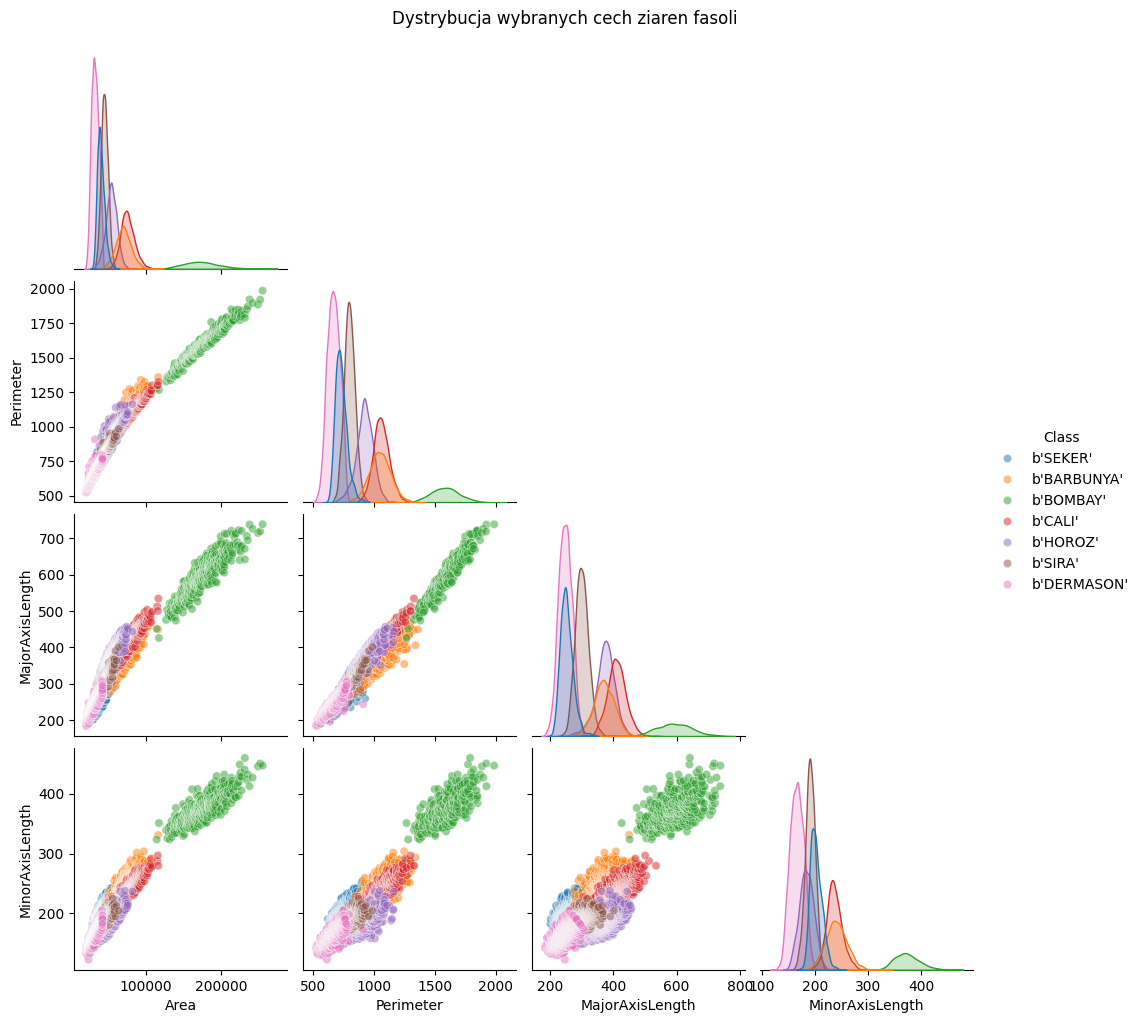

In [ ]:
X_raw = df.drop(columns=['Class'])
y_true = df['Class']

print("Podstawowe statystyki zbioru:")
display(X_raw.describe())


selected_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Class']
sns.pairplot(df[selected_features], hue='Class', palette='tab10', corner=True, plot_kws={'alpha': 0.5})
plt.suptitle('Dystrybucja wybranych cech ziaren fasoli', y=1.02)
plt.show()

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

## 2. Algorytm k-średnich

### 2.1 Przygotowanie
Ponieważ zbiór ma 16 wymiarów, nie możemy go bezpośrednio narysować na płaszczyźnie 2D. Wykorzystamy algorytm PCA, aby zredukować wymiarowość do 2 tylko na potrzeby wizualizacji klastrów.

Inercja dla k=7: 48811.96


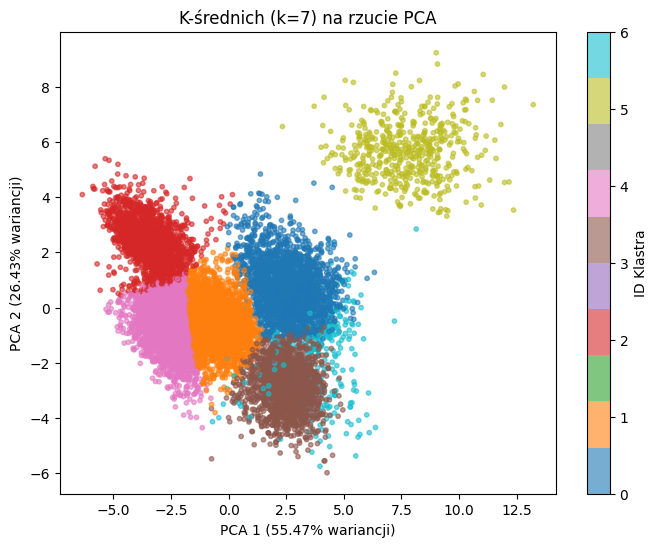

In [ ]:
def plot_clusters(X, labels, title):

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.title(title)
    plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.2%} wariancji)")
    plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.2%} wariancji)")
    plt.colorbar(scatter, label='ID Klastra')
    plt.show()

#7 liczba gatunków
kmeans_initial = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init='auto')
labels_initial = kmeans_initial.fit_predict(X_scaled)

print(f"Inercja dla k=7: {kmeans_initial.inertia_:.2f}")
plot_clusters(X_scaled, labels_initial, "K-średnich (k=7) na rzucie PCA")

### 2.2 Badanie wpływu parametru k
Sprawdzimy wartości k w zakresie od 2 do 12. Obliczymy inercję, silhouette oraz purity.

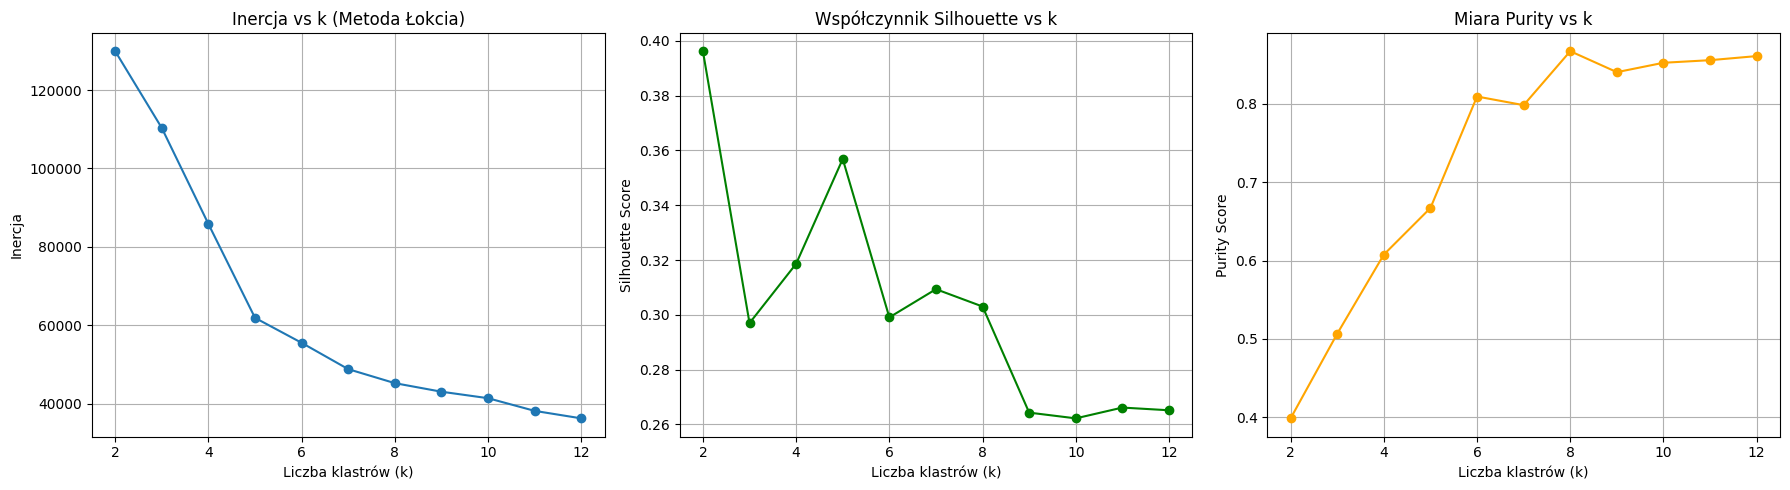

In [ ]:
k_values = range(2, 13)
inertia_scores = []
silhouette_scores = []
purity_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_scaled)
    
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    purity_scores.append(purity_score(y_true, labels))



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_values, inertia_scores, marker='o')
axes[0].set_title('Inercja vs k (Metoda Łokcia)')
axes[0].set_xlabel('Liczba klastrów (k)')
axes[0].set_ylabel('Inercja')
axes[0].grid(True)

axes[1].plot(k_values, silhouette_scores, marker='o', color='green')
axes[1].set_title('Współczynnik Silhouette vs k')
axes[1].set_xlabel('Liczba klastrów (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

axes[2].plot(k_values, purity_scores, marker='o', color='orange')
axes[2].set_title('Miara Purity vs k')
axes[2].set_xlabel('Liczba klastrów (k)')
axes[2].set_ylabel('Purity Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 3. Klasteryzacja aglomeracyjna

### 3.1 Badanie
Zbadamy ten sam zakres k dla metody aglomeracyjnej (hierarchicznej). Ponieważ algorytm aglomeracyjny nie optymalizuje inercji w takim sensie jak k-średnich, przeanalizujemy tylko silhouette i purity

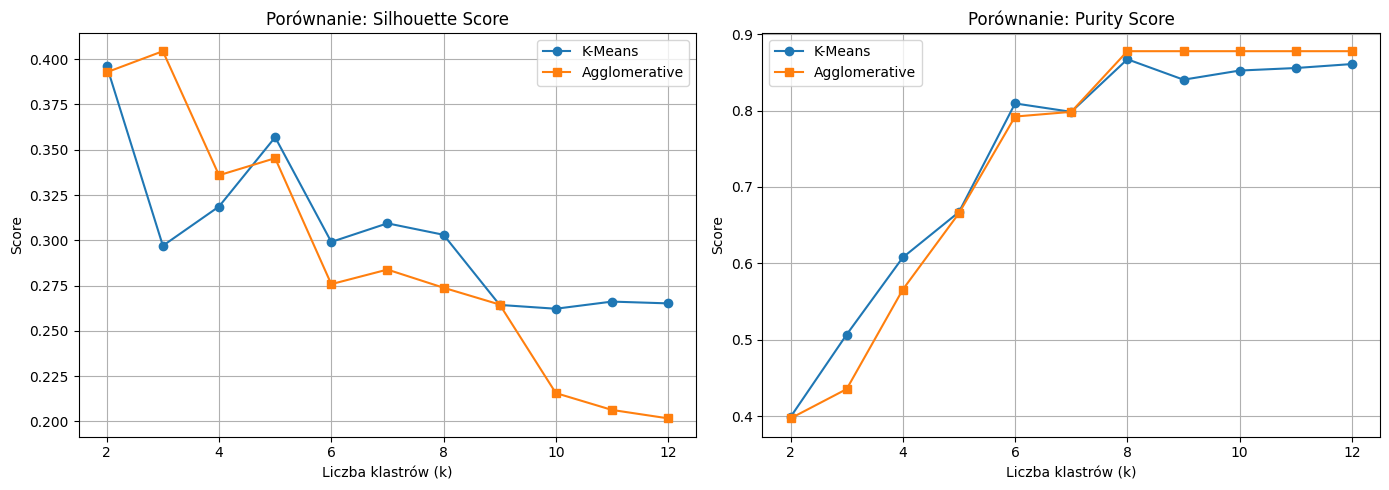

In [ ]:
agg_silhouette = []
agg_purity = []


for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(X_scaled)
    
    agg_silhouette.append(silhouette_score(X_scaled, labels))
    agg_purity.append(purity_score(y_true, labels))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, silhouette_scores, marker='o', label='K-Means')
axes[0].plot(k_values, agg_silhouette, marker='s', label='Agglomerative')
axes[0].set_title('Porównanie: Silhouette Score')
axes[0].set_xlabel('Liczba klastrów (k)')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(k_values, purity_scores, marker='o', label='K-Means')
axes[1].plot(k_values, agg_purity, marker='s', label='Agglomerative')
axes[1].set_title('Porównanie: Purity Score')
axes[1].set_xlabel('Liczba klastrów (k)')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3.2 Pomiar czasu
Do rygorystycznego pomiaru czasu w języku Python najlepiej sprawdza się moduł time i funkcja time.perf_counter(), która gwarantuje najwyższą dostępną rozdzielczość zegara do mierzenia krótkich odcinków czasowych.

In [ ]:
k_test = 7


start_time = time.perf_counter()
km = KMeans(n_clusters=k_test, random_state=RANDOM_STATE, n_init='auto')
km.fit(X_scaled)
kmeans_time = time.perf_counter() - start_time


start_time = time.perf_counter()
agg = AgglomerativeClustering(n_clusters=k_test, metric='euclidean', linkage='ward')
agg.fit(X_scaled)
agg_time = time.perf_counter() - start_time

print("--- Wyniki pomiaru czasu ---")
print(f"K-Means (k={k_test}):           {kmeans_time:.4f} sekund")
print(f"Agglomerative (k={k_test}):     {agg_time:.4f} sekund")
print(f"Różnica (mnożnik): Algorytm K-Means był {agg_time/kmeans_time:.2f} razy szybszy.")

--- Wyniki pomiaru czasu ---
K-Means (k=7):           0.0217 sekund
Agglomerative (k=7):     4.3551 sekund
Różnica (mnożnik):          Algorytm K-Means był 200.95 razy szybszy.
